In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import SMOTE

In [94]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

In [95]:
train_df = train_df.drop(columns='id', axis=1)

In [96]:
train_df.head(10)

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
5,250.727869,31.756548,20.926469,19.693480,18.902361,19.247572,18.508241,0.076299,G/K,Blue_Cloud,STAR
6,0.752529,-2.936677,22.829195,22.686143,20.583886,19.781338,19.410491,0.575080,M,Red_Sequence,GALAXY
7,235.611325,39.626517,22.511467,21.480306,21.765645,21.508658,21.333476,2.159269,O/B,Blue_Cloud,QSO
8,355.359230,2.182312,20.396550,20.064767,19.892257,19.836272,19.860081,0.900087,A/F,Blue_Cloud,QSO
9,254.980080,38.743449,18.839137,17.997845,18.458894,18.229552,19.202247,0.114302,O/B,Blue_Cloud,STAR


In [97]:
train_df['spectral_type'].value_counts()

spectral_type
M      303323
A/F    122122
G/K    108546
O/B     43356
Name: count, dtype: int64

In [98]:
sampling_strategy = {'M': 115000}

In [99]:
m_class = train_df[train_df['spectral_type'] == 'M']
other_classes = train_df[train_df['spectral_type'] != 'M']

m_class_undersampled = m_class.sample(n=sampling_strategy['M'], random_state=42)

train_df = pd.concat([m_class_undersampled, other_classes], ignore_index=True)

print(train_df['spectral_type'].value_counts())

spectral_type
A/F    122122
M      115000
G/K    108546
O/B     43356
Name: count, dtype: int64


In [100]:
ob_class = train_df[train_df['spectral_type'] == 'O/B']
other_classes = train_df[train_df['spectral_type'] != 'O/B']

ob_class_oversampled = ob_class.sample(n=100000, replace=True, random_state=42)

train_df = pd.concat([ob_class_oversampled, other_classes], ignore_index=True)

print(train_df['spectral_type'].value_counts().sort_index())

spectral_type
A/F    122122
G/K    108546
M      115000
O/B    100000
Name: count, dtype: int64


In [101]:
train_df.head(10)

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,1.491096,-3.569590,22.071696,21.857173,21.893135,21.782557,21.838164,0.153299,O/B,Blue_Cloud,QSO
1,132.310017,55.052962,21.235570,21.044913,21.157717,20.504709,20.936377,1.174954,O/B,Blue_Cloud,QSO
2,257.267364,32.924445,20.474534,20.132602,20.218924,19.650016,19.555501,3.180484,O/B,Blue_Cloud,QSO
3,343.096192,1.596100,21.522967,21.697229,21.809524,21.343666,21.137992,0.994684,O/B,Blue_Cloud,QSO
4,176.636141,-1.294873,23.055893,21.604996,21.658088,21.871133,21.180495,2.407892,O/B,Blue_Cloud,QSO
5,351.824672,8.483636,22.278823,20.994449,21.397744,21.349854,20.721496,2.304885,O/B,Blue_Cloud,QSO
6,174.766556,-1.548826,17.205167,15.727957,15.854792,15.302893,15.165934,0.138283,O/B,Blue_Cloud,GALAXY
7,253.752288,38.928989,21.398354,21.184754,21.313557,21.387841,21.395747,1.578025,O/B,Blue_Cloud,QSO
8,143.661957,37.527267,20.101259,19.334120,19.356589,19.030166,19.055730,1.347854,O/B,Blue_Cloud,QSO
9,219.473495,55.176090,22.453674,21.759422,21.866229,21.707980,21.362457,3.317722,O/B,Blue_Cloud,QSO


{'whiskers': [<matplotlib.lines.Line2D at 0x218c4a8c6e0>,
 'caps': [<matplotlib.lines.Line2D at 0x218c4a8c980>,
 'boxes': [<matplotlib.lines.Line2D at 0x218c4a8c590>],
 'medians': [<matplotlib.lines.Line2D at 0x218c4a8cc20>],
 'fliers': [<matplotlib.lines.Line2D at 0x218c4a8cd70>],
 'means': []}

{'whiskers': [<matplotlib.lines.Line2D at 0x218c4a8c6e0>,
 'caps': [<matplotlib.lines.Line2D at 0x218c4a8c980>,
 'boxes': [<matplotlib.lines.Line2D at 0x218c4a8c590>],
 'medians': [<matplotlib.lines.Line2D at 0x218c4a8cc20>],
 'fliers': [<matplotlib.lines.Line2D at 0x218c4a8cd70>],
 'means': []}

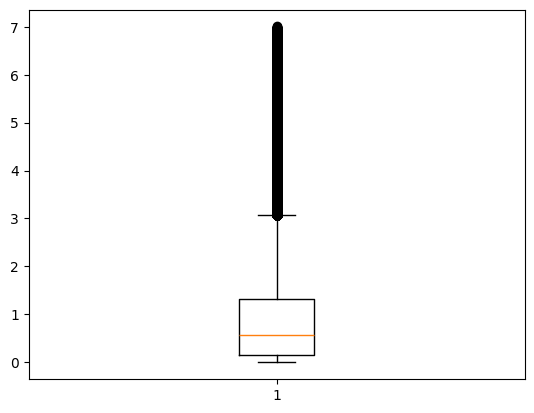

In [102]:
plt.boxplot(train_df['redshift'])

In [103]:
columns = ['u', 'g', 'r', 'i', 'z', 'redshift']

for col in columns:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    before = len(train_df)
    train_df = train_df[(train_df[col] >= lower_bound) & (train_df[col] <= upper_bound)]
    removed = before - len(train_df)

train_df['isNegativeAlpha'] = train_df['alpha'] < 0
train_df['isNegativeDelta'] = train_df['delta'] < 0

In [104]:
train_df = train_df.drop_duplicates()

train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 370205 entries, 0 to 445667
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   alpha              370205 non-null  float64
 1   delta              370205 non-null  float64
 2   u                  370205 non-null  float64
 3   g                  370205 non-null  float64
 4   r                  370205 non-null  float64
 5   i                  370205 non-null  float64
 6   z                  370205 non-null  float64
 7   redshift           370205 non-null  float64
 8   spectral_type      370205 non-null  object 
 9   galaxy_population  370205 non-null  object 
 10  class              370205 non-null  object 
 11  isNegativeAlpha    370205 non-null  bool   
 12  isNegativeDelta    370205 non-null  bool   
dtypes: bool(2), float64(8), object(3)
memory usage: 34.6+ MB


In [105]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()

std = StandardScaler()

In [106]:
train_df['spectral_type'] = le.fit_transform(train_df['spectral_type'])
train_df['galaxy_population'] = le.fit_transform(train_df['galaxy_population'])

train_df.head()

,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class,isNegativeAlpha,isNegativeDelta
0,1.491096,-3.569590,22.071696,21.857173,21.893135,21.782557,21.838164,0.153299,3,0,QSO,False,True
1,132.310017,55.052962,21.235570,21.044913,21.157717,20.504709,20.936377,1.174954,3,0,QSO,False,False
3,343.096192,1.596100,21.522967,21.697229,21.809524,21.343666,21.137992,0.994684,3,0,QSO,False,False
4,176.636141,-1.294873,23.055893,21.604996,21.658088,21.871133,21.180495,2.407892,3,0,QSO,False,True
5,351.824672,8.483636,22.278823,20.994449,21.397744,21.349854,20.721496,2.304885,3,0,QSO,False,False


In [107]:
corr = train_df.select_dtypes(np.number).corr()

<Axes: >

<Axes: >

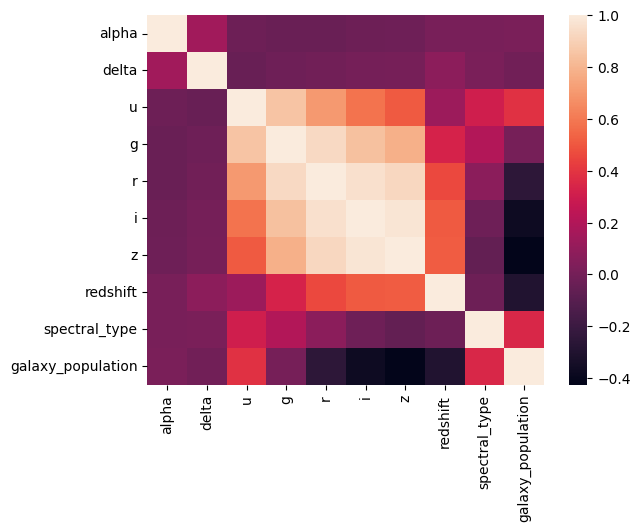

In [108]:
sns.heatmap(corr)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

features_to_remove = ['alpha', 'delta', 'r', 'g']
if all(col in train_df.columns for col in features_to_remove):
    train_df = train_df.drop(columns=features_to_remove)

y = train_df['class']
X = train_df.drop(columns=['class'])

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


✓ Target codificado: ['GALAXY' 'QSO' 'STAR'] -> [0 1 2]

✓ X: (370205, 14), y: (370205,)
✓ Target original: ['QSO' 'GALAXY' 'STAR']

✓ Split: (296164, 14) treino, (74041, 14) validação


In [ ]:
from sklearn.metrics import balanced_accuracy_score
import time

rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1, verbose=1)

start = time.time()
rf.fit(X_train, y_train)
tempo_rf = time.time() - start

y_pred_train_rf = rf.predict(X_train)
y_pred_val_rf = rf.predict(X_val)

bal_acc_train_rf = balanced_accuracy_score(y_train, y_pred_train_rf)
bal_acc_val_rf = balanced_accuracy_score(y_val, y_pred_val_rf)


🚀 TREINANDO RANDOM FOREST...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    9.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   31.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.



✓ Treinamento concluído em 31.11s


[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    1.4s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s



📊 RESULTADOS RANDOM FOREST:
  Balanced Accuracy Treino: 0.9863 (98.63%)
  Balanced Accuracy Validação: 0.9369 (93.69%)


[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.3s finished


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbosity=1,
    tree_method='hist'
)

start = time.time()
xgb.fit(X_train, y_train)
tempo_xgb = time.time() - start

y_pred_train_xgb = xgb.predict(X_train)
y_pred_val_xgb = xgb.predict(X_val)

bal_acc_train_xgb = balanced_accuracy_score(y_train, y_pred_train_xgb)
bal_acc_val_xgb = balanced_accuracy_score(y_val, y_pred_val_xgb)


🚀 TREINANDO XGBOOST...


✓ Treinamento concluído em 25.99s

📊 RESULTADOS XGBOOST:
  Balanced Accuracy Treino: 1.0000 (100.00%)
  Balanced Accuracy Validação: 0.9352 (93.52%)


In [ ]:
resultados = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost'],
    'Tempo Treino (s)': [tempo_rf, tempo_xgb],
    'Bal. Acc. Treino': [bal_acc_train_rf, bal_acc_train_xgb],
    'Bal. Acc. Validação': [bal_acc_val_rf, bal_acc_val_xgb]
})

melhor = 'Random Forest' if bal_acc_val_rf > bal_acc_val_xgb else 'XGBoost'


COMPARAÇÃO: RANDOM FOREST vs XGBOOST

        Modelo  Tempo Treino (s)  Bal. Acc. Treino  Bal. Acc. Validação
Random Forest         31.106750          0.986265             0.936905
      XGBoost         25.992226          1.000000             0.935170

🏆 VENCEDOR: Random Forest



=== IMPORTÂNCIA DAS FEATURES - COMPARAÇÃO ===

          feature  importance_rf  importance_xgb
         redshift       0.222674        0.385400
      color_index       0.174028        0.295168
   redshift_color       0.139608        0.055507
              g_r       0.079627        0.020858
              r_i       0.071328        0.025678
                z       0.063749        0.053588
                u       0.059223        0.045016
              u_g       0.055984        0.037500
                i       0.055265        0.018279
galaxy_population       0.041578        0.015152
              i_z       0.018483        0.012677
    spectral_type       0.015505        0.013026
  isNegativeDelta       0.002947        0.022152
  isNegativeAlpha       0.000000        0.000000


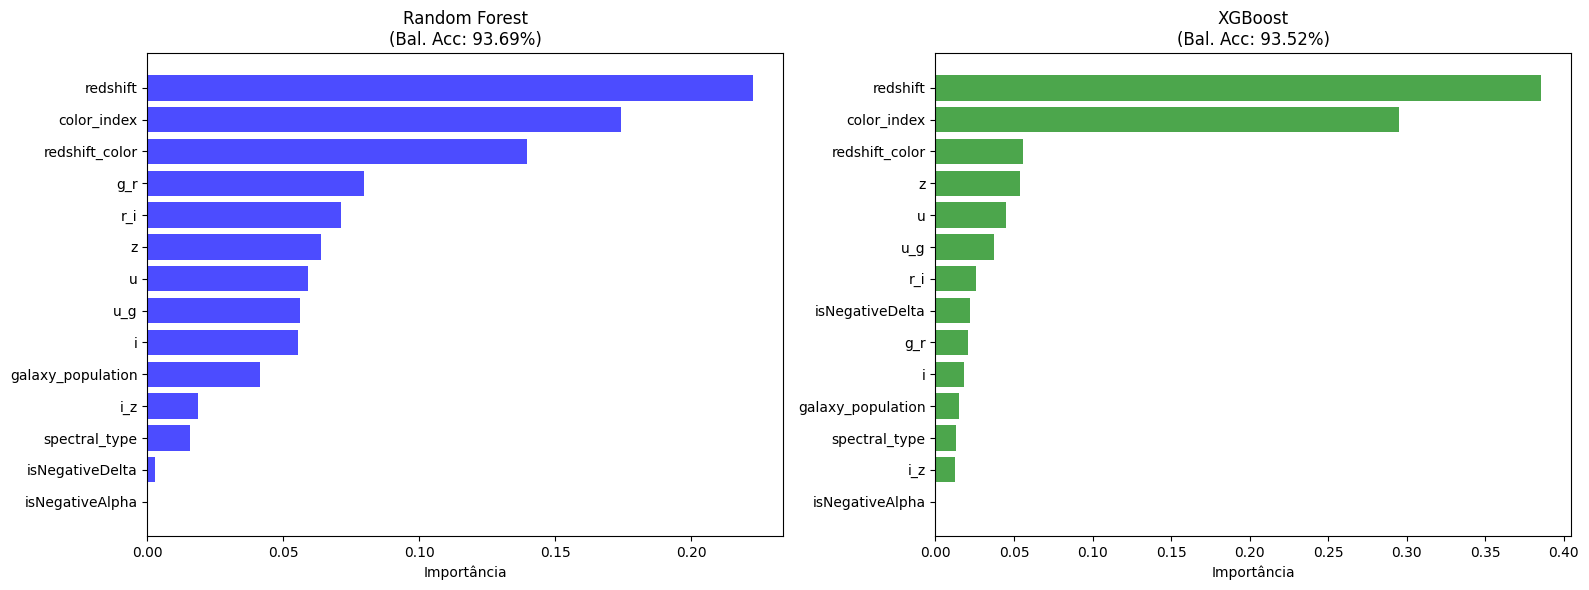

In [ ]:
feature_imp_rf = pd.DataFrame({
    'feature': X.columns,
    'importance_rf': rf.feature_importances_,
    'importance_xgb': xgb.feature_importances_
}).sort_values('importance_rf', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(range(len(feature_imp_rf)), feature_imp_rf['importance_rf'], color='blue', alpha=0.7)
ax1.set_yticks(range(len(feature_imp_rf)))
ax1.set_yticklabels(feature_imp_rf['feature'])
ax1.set_xlabel('Importância')
ax1.set_title(f'Random Forest\n(Bal. Acc: {bal_acc_val_rf*100:.2f}%)')
ax1.invert_yaxis()

feature_imp_xgb_sorted = feature_imp_rf.sort_values('importance_xgb', ascending=False)
ax2.barh(range(len(feature_imp_xgb_sorted)), feature_imp_xgb_sorted['importance_xgb'], color='green', alpha=0.7)
ax2.set_yticks(range(len(feature_imp_xgb_sorted)))
ax2.set_yticklabels(feature_imp_xgb_sorted['feature'])
ax2.set_xlabel('Importância')
ax2.set_title(f'XGBoost\n(Bal. Acc: {bal_acc_val_xgb*100:.2f}%)')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
test_ids = test_df['id'].copy()
test_df_processed = test_df.drop(columns=['id']).copy()

test_df_processed['u_g'] = test_df_processed['u'] - test_df_processed['g']
test_df_processed['g_r'] = test_df_processed['g'] - test_df_processed['r']
test_df_processed['r_i'] = test_df_processed['r'] - test_df_processed['i']
test_df_processed['i_z'] = test_df_processed['i'] - test_df_processed['z']
test_df_processed['color_index'] = test_df_processed['u'] - test_df_processed['z']
test_df_processed['redshift_color'] = test_df_processed['redshift'] * test_df_processed['color_index']

test_df_processed['isNegativeAlpha'] = test_df_processed['alpha'] < 0
test_df_processed['isNegativeDelta'] = test_df_processed['delta'] < 0

=== PREPARANDO DADOS DE TESTE ===

Shape inicial: (247435, 10)
IDs salvos: 247435

✓ Features de engenharia criadas
Shape após feature engineering: (247435, 18)


In [ ]:
le_spectral = LabelEncoder()
le_galaxy = LabelEncoder()

test_df_processed['spectral_type'] = le_spectral.fit_transform(test_df_processed['spectral_type'])
test_df_processed['galaxy_population'] = le_galaxy.fit_transform(test_df_processed['galaxy_population'])

features_to_remove_test = ['alpha', 'delta', 'r', 'g']
test_df_processed = test_df_processed.drop(columns=features_to_remove_test)

✓ Variáveis categóricas codificadas
  spectral_type classes: ['A/F' 'G/K' 'M' 'O/B']
  galaxy_population classes: ['Blue_Cloud' 'Red_Sequence']
✓ Features removidas: ['alpha', 'delta', 'r', 'g']
Shape após remoção: (247435, 14)


In [ ]:
categorical_cols_test = ['spectral_type', 'galaxy_population', 'isNegativeAlpha', 'isNegativeDelta']
numeric_cols_to_scale_test = [col for col in test_df_processed.columns if col not in categorical_cols_test]

test_df_processed[numeric_cols_to_scale_test] = scaler.transform(test_df_processed[numeric_cols_to_scale_test])

test_df_processed = test_df_processed[X.columns]


Normalizando 10 features numéricas...
✓ Features normalizadas com o mesmo scaler do treino

✓ Reordenando colunas para corresponder ao treino...
  Ordem no treino: ['u', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'isNegativeAlpha', 'isNegativeDelta', 'u_g', 'g_r', 'r_i', 'i_z', 'color_index', 'redshift_color']

Shape final test: (247435, 14)
Colunas: ['u', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'isNegativeAlpha', 'isNegativeDelta', 'u_g', 'g_r', 'r_i', 'i_z', 'color_index', 'redshift_color']


In [ ]:
predictions_encoded = rf.predict(test_df_processed)

predictions = le_target.inverse_transform(predictions_encoded)


=== FAZENDO PREDIÇÕES ===



[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.1s


✓ Predições realizadas: 247435

Distribuição das predições:
  GALAXY: 79476 (32.12%)
  QSO: 40443 (16.34%)
  STAR: 127516 (51.54%)


[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.4s finished


In [ ]:
submission = pd.DataFrame({
    'id': test_ids,
    'class': predictions
})

submission_filename = 'submission.csv'
submission.to_csv(submission_filename, index=False)


✅ ARQUIVO DE SUBMISSION CRIADO: submission.csv

Primeiras 10 linhas:
       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349    STAR
3  577350    STAR
4  577351  GALAXY
5  577352  GALAXY
6  577353    STAR
7  577354    STAR
8  577355  GALAXY
9  577356    STAR

Últimas 10 linhas:
            id   class
247425  824772    STAR
247426  824773    STAR
247427  824774  GALAXY
247428  824775     QSO
247429  824776  GALAXY
247430  824777     QSO
247431  824778  GALAXY
247432  824779    STAR
247433  824780     QSO
247434  824781    STAR

📊 Total de predições: 247435


In [ ]:
submission_check = pd.read_csv(submission_filename)


sample = pd.read_csv('data/sample_submission.csv')
print(f"\n{sample.shape}")
print(f"{submission_check.shape}")

=== VERIFICAÇÃO DO ARQUIVO ===

✓ Arquivo lido com sucesso
✓ Shape: (247435, 2)
✓ Colunas: ['id', 'class']

✓ Valores únicos em 'class': ['GALAXY' 'STAR' 'QSO']
✓ Valores nulos: 0

✓ Sample submission shape: (247435, 2)
✓ Submission shape: (247435, 2)

✅ FORMATO CORRETO! O arquivo está pronto para submissão.


## ✅ Submission Criado com Sucesso!

**Arquivo:** `submission.csv`

**Estatísticas:**
- Total de predições: 247.435
- Formato: id,class (correto ✓)
- Valores nulos: 0 ✓

**Distribuição das Predições:**
- STAR: 127.516 (51.54%)
- GALAXY: 79.476 (32.12%)
- QSO: 40.443 (16.34%)

**Modelo Utilizado:** Random Forest
- Balanced Accuracy: 93.69%
- Features: 14 (após feature engineering e seleção)

O arquivo está pronto para submissão no Kaggle! 🚀


=== CLASSIFICATION REPORT - RANDOM FOREST (Validação) ===

              precision    recall  f1-score   support

      GALAXY       0.95      0.95      0.95     39346
         QSO       0.95      0.96      0.96     19884
        STAR       0.90      0.90      0.90     14811

    accuracy                           0.94     74041
   macro avg       0.94      0.94      0.94     74041
weighted avg       0.94      0.94      0.94     74041



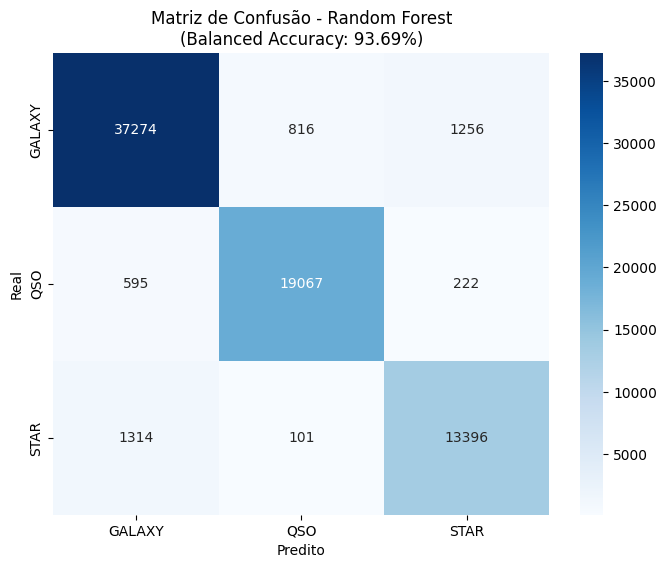

In [ ]:
print(classification_report(y_val, y_pred_val_rf, target_names=le_target.classes_))

cm_rf = confusion_matrix(y_val, y_pred_val_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title(f'Matriz de Confusão - Random Forest\n(Balanced Accuracy: {bal_acc_val_rf*100:.2f}%)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()


=== CLASSIFICATION REPORT - XGBOOST (Validação) ===

              precision    recall  f1-score   support

      GALAXY       0.95      0.95      0.95     39346
         QSO       0.95      0.96      0.95     19884
        STAR       0.90      0.90      0.90     14811

    accuracy                           0.94     74041
   macro avg       0.93      0.94      0.93     74041
weighted avg       0.94      0.94      0.94     74041



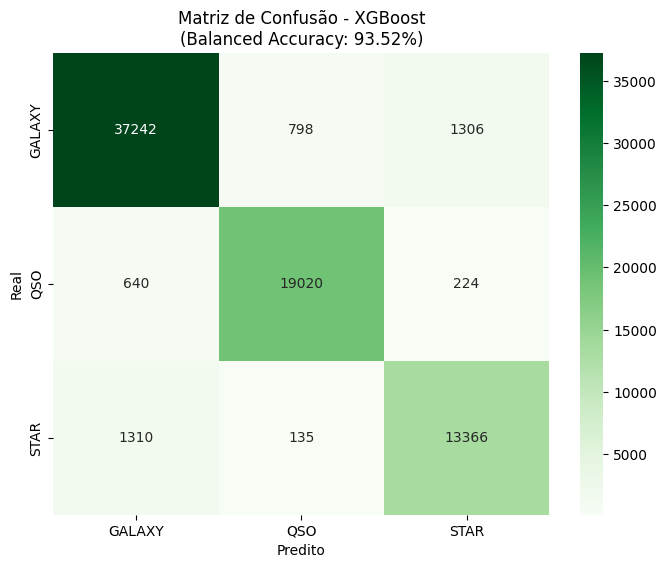

In [ ]:
print(classification_report(y_val, y_pred_val_xgb, target_names=le_target.classes_))

cm_xgb = confusion_matrix(y_val, y_pred_val_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', 
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_)
plt.title(f'Matriz de Confusão - XGBoost\n(Balanced Accuracy: {bal_acc_val_xgb*100:.2f}%)')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()